In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Any

In [2]:
RANDOM_STATE = 42

In [3]:
import os

DATA_FOLDER = "data"
PATH = f"{DATA_FOLDER}/bank_marketing.csv"
SEP = ";"

if os.path.isfile(PATH):
    df = pd.read_csv(PATH, sep=SEP)
    X = df.drop(df.columns[-1], axis=1)
    y = df.drop(df.columns[:-1], axis=1)
else:
    from ucimlrepo import fetch_ucirepo
    bank_marketing = fetch_ucirepo(id=222)
    X = bank_marketing.data.features
    y = bank_marketing.data.targets
    df = X.join(y)
    os.makedirs(DATA_FOLDER, exist_ok=True)
    df.to_csv(PATH, sep=SEP, index=False)

In [4]:
X

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN


In [5]:
y.value_counts()

y  
no     39922
yes     5289
Name: count, dtype: int64

In [6]:
target = y.columns[0]

In [7]:
# This attribute highly affects the output targe. Yet, the duration is not known before a call is performed
X = X.drop(labels=["duration"], axis=1)

In [8]:
for c in X.columns:
    print(f"{c:<20}{len(X[c].unique())}")

age                 77
job                 12
marital             3
education           4
default             2
balance             7168
housing             2
loan                2
contact             3
day_of_week         31
month               12
campaign            48
pdays               559
previous            41
poutcome            4


In [9]:
from sklearn.preprocessing import LabelEncoder

y_encoder = LabelEncoder()
y_encoded = y_encoder.fit_transform(y[target])

In [10]:
from sklearn.preprocessing import OrdinalEncoder

month_encoder = OrdinalEncoder(dtype=int, categories=[["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]])
X_encoded_month = month_encoder.fit_transform(X["month"].to_frame())

X["month"] = X_encoded_month

X_encoded = pd.get_dummies(
    data=X,
    dtype=int,
    dummy_na=True,
    drop_first=True,
    columns=["job", "marital", "education", "default", "housing", "loan", "contact", "poutcome"]
)

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded.values, y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True
)

In [12]:
len(X_encoded.columns)

35

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate

Estimator = Any

def cross_validation(estimator: Estimator, X, y, params: dict | None = None) -> np.ndarray:
    if params is None:
        params = {}

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    cv_result = cross_validate(
        estimator=estimator,
        X=X,
        y=y,
        return_estimator=True,
        return_indices=True,
        cv=cv,
        n_jobs=-1,
        params=params,
    )

    test_indices = cv_result["indices"]["test"]
    estimators = cv_result["estimator"]

    n_classes = len(np.unique(y))
    y_val_scores = np.empty((y.shape[0], n_classes))

    # Out-of-fold
    for i, e in enumerate(estimators):
        test_idx = test_indices[i]
        X_val_i = X[test_idx]
        y_val_scores[test_idx] = e.predict_proba(X_val_i)

    return y_val_scores[:, 1]

In [14]:
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score

def metrics(y_true, y_scores) -> tuple[float, float]:
    roc_auc = roc_auc_score(y_true, y_scores)
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)

    return roc_auc, pr_auc

In [15]:
import warnings
from scipy.linalg import LinAlgWarning
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

svm = Pipeline([
    ("scaler", StandardScaler(),),
    ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),),
])
calibrated_svm = CalibratedClassifierCV(svm, method='sigmoid')

lr = Pipeline([
    ("scaler", StandardScaler(),),
    ("clf", LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced"),),
])

naive_bayes = Pipeline([
    ("scaler", StandardScaler(),),
    ("clf", GaussianNB(),),
])

base_models = [
    ("LDA", LinearDiscriminantAnalysis(),),
    ("QDA", QuadraticDiscriminantAnalysis(reg_param=0.0001),),
    ("SVM", calibrated_svm,),
    ("NB", naive_bayes,),
    ("LR", lr,),
    ("RF", RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=300, max_depth=10, class_weight="balanced_subsample"),),
    ("GB", GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=104, max_depth=4),),
    ("ET", ExtraTreesClassifier(random_state=RANDOM_STATE, max_depth=4, class_weight="balanced", n_estimators=90),),
]

print(f"{'':<11}{'ROC-AUC':<11}PR-AUC\n")
data = []
warnings.filterwarnings(action="ignore", category=LinAlgWarning)
for label, estimator in base_models:
    y_scores = cross_validation(estimator, X_train, y_train)
    y_true = y_train
    roc_auc, pr_auc = metrics(y_true, y_scores)
    data.append((label, pr_auc, y_scores))
    print(f"{label:<11}{round(roc_auc, 2):<11}{round(pr_auc, 2)}")

           ROC-AUC    PR-AUC

LDA        0.74       0.35
QDA        0.72       0.34
SVM        0.75       0.36
NB         0.71       0.34
LR         0.75       0.36
RF         0.78       0.41
GB         0.8        0.44
ET         0.74       0.36


In [16]:
def draw_heat_map(corr_matrix: pd.DataFrame) -> None:
    sns.heatmap(data=corr_matrix, cmap='coolwarm', annot=True, annot_kws={"fontsize": 7})

In [17]:
oofs = pd.DataFrame({it[0]:it[2] for it in data})

In [25]:
oofs

,LDA,QDA,SVM,NB,LR,RF,GB,ET
0,0.022354,7.549211e-05,0.023861,3.053292e-05,0.181803,0.244049,0.037719,0.291765
1,0.038163,7.660348e-03,0.058243,8.056758e-03,0.333580,0.373881,0.071531,0.438303
2,0.088033,4.919634e-02,0.134044,1.545491e-02,0.524401,0.424158,0.108457,0.504052
3,0.024174,4.885038e-07,0.018919,2.928495e-07,0.142972,0.218974,0.043952,0.336082
4,0.082412,6.778790e-03,0.115869,8.590838e-03,0.491862,0.570995,0.247935,0.484604
...,...,...,...,...,...,...,...,...
36163,0.044858,1.385520e-06,0.050085,8.103855e-06,0.302276,0.254900,0.046566,0.368480
36164,0.371270,1.000000e+00,0.394682,1.000000e+00,0.803303,0.771739,0.644587,0.692899
36165,0.071549,4.189231e-02,0.125021,2.200486e-02,0.516106,0.469565,0.108421,0.482357
36166,0.090075,1.289971e-02,0.094124,9.505419e-02,0.440899,0.217926,0.039898,0.366614


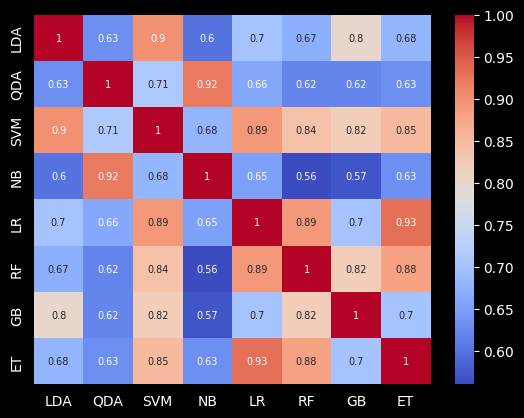

In [18]:
draw_heat_map(oofs.corr().round(2))

In [19]:
class BlendingClassifier:
    def __init__(
            self,
            estimators: list[Any],
            final_estimator: Any,
            blend_method: str = "predict_proba",
            meta_size: float = 0.2,
            passthrough: bool = False,
    ):
        self.__estimators = estimators
        self.__final_estimator = final_estimator
        self.__meta_size = meta_size
        self.__passthrough = passthrough
        self.__blend_method = blend_method

        if blend_method == "predict_proba":
            self.__transform_function = lambda est, X: est.predict_proba(X)[:, 1]
        elif blend_method == "predict":
            self.__transform_function = lambda est, X: est.predict(X)
        else:
            self.__transform_function = lambda est, X: est.decision_function(X)

    def fit(self, X, y):
        X_base, X_meta, y_base, y_meta = train_test_split(
            X, y,
            test_size=self.__meta_size,
            random_state=RANDOM_STATE,
            shuffle=True
        )

        for _, est in self.__estimators:
            est.fit(X_base, y_base)

        X_meta_transformed = self.transform(X_meta)
        self.__final_estimator.fit(X_meta_transformed, y_meta)

    def predict_proba(self, X):
        return self.__final_estimator.predict_proba(self.transform(X))

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

    def transform(self, X) -> np.ndarray:
        offset = X.shape[1] if self.__passthrough else 0

        result = np.empty((X.shape[0], offset + len(self.__estimators)))

        if offset > 0:
            result[:, :offset] = X

        for i, (_, est) in enumerate(self.__estimators):
            result[:, offset + i] = self.__transform_function(est, X)

        return result

    def score(self, X, y):
        return self.__final_estimator.score(self.transform(X), y)

    def get_params(self, deep=True):
        return {
            "estimators": self.__estimators,
            "final_estimator": self.__final_estimator,
            "blend_method": self.__blend_method,
            "meta_size": self.__meta_size,
            "passthrough": self.__passthrough,
        }

In [20]:
class BiasedEnsembleClassifier:
    def __init__(
            self,
            estimators: list[Any],
            final_estimator: Any,
            combine_method: str = "predict_proba",
            passthrough: bool = False,
    ):
        self.__estimators = estimators
        self.__final_estimator = final_estimator
        self.__passthrough = passthrough
        self.__blend_method = combine_method

        if combine_method == "predict_proba":
            self.__transform_function = lambda est, X: est.predict_proba(X)[:, 1]
        elif combine_method == "predict":
            self.__transform_function = lambda est, X: est.predict(X)
        else:
            self.__transform_function = lambda est, X: est.decision_function(X)

    def fit(self, X, y):
        for _, est in self.__estimators:
            est.fit(X, y)

        X_transformed = self.transform(X)
        self.__final_estimator.fit(X_transformed, y)

    def predict_proba(self, X):
        return self.__final_estimator.predict_proba(self.transform(X))

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

    def transform(self, X) -> np.ndarray:
        offset = X.shape[1] if self.__passthrough else 0

        result = np.empty((X.shape[0], offset + len(self.__estimators)))

        if offset > 0:
            result[:, :offset] = X

        for i, (_, est) in enumerate(self.__estimators):
            result[:, offset + i] = self.__transform_function(est, X)

        return result

    def score(self, X, y):
        return self.__final_estimator.score(self.transform(X), y)

    def get_params(self, deep=True):
        return {
            "estimators": self.__estimators,
            "final_estimator": self.__final_estimator,
            "combine_method": self.__blend_method,
            "passthrough": self.__passthrough,
        }

In [21]:
def get_final_estimator():
    return LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, solver="newton-cholesky")

In [22]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

models_for_ensemble = [base_models[0], base_models[4], base_models[6]]  # LDA + LR + GB

# TODO: try averaging not probabilities (predict_proba), but values from decision_function()
soft_voting_clf = VotingClassifier(estimators=models_for_ensemble, voting="soft", weights=[0.001, 0.015, 1])

blending_clf = BlendingClassifier(
    estimators=models_for_ensemble,
    final_estimator=get_final_estimator(),
    blend_method="decision_function",
    meta_size=0.2
)

stacking_clf = StackingClassifier(
    estimators=models_for_ensemble,
    final_estimator=get_final_estimator(),
    stack_method="decision_function",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
)

biased_clf = BiasedEnsembleClassifier(
    estimators=models_for_ensemble,
    final_estimator=get_final_estimator(),
    combine_method="predict_proba",
)

all_models = base_models + [
    ("SoftVoting", soft_voting_clf,),
    ("Blending", blending_clf,),
    ("Stacking", stacking_clf,),
    ("BiasedStacking", biased_clf,),
]

In [23]:
scores = {
    "train": [],
    "validation": [],
    "test": [],
}

for label, est in all_models:
    est.fit(X_train, y_train)
    y_score_train = est.predict_proba(X_train)[:, 1]
    y_score_val = cross_validation(est, X_train, y_train)
    y_score_test = est.predict_proba(X_test)[:, 1]

    _, pr_auc_train = metrics(y_train, y_score_train)
    _, pr_auc_val = metrics(y_train, y_score_val)
    _, pr_auc_test = metrics(y_test, y_score_test)

    scores["train"].append(pr_auc_train)
    scores["validation"].append(pr_auc_val)
    scores["test"].append(pr_auc_test)

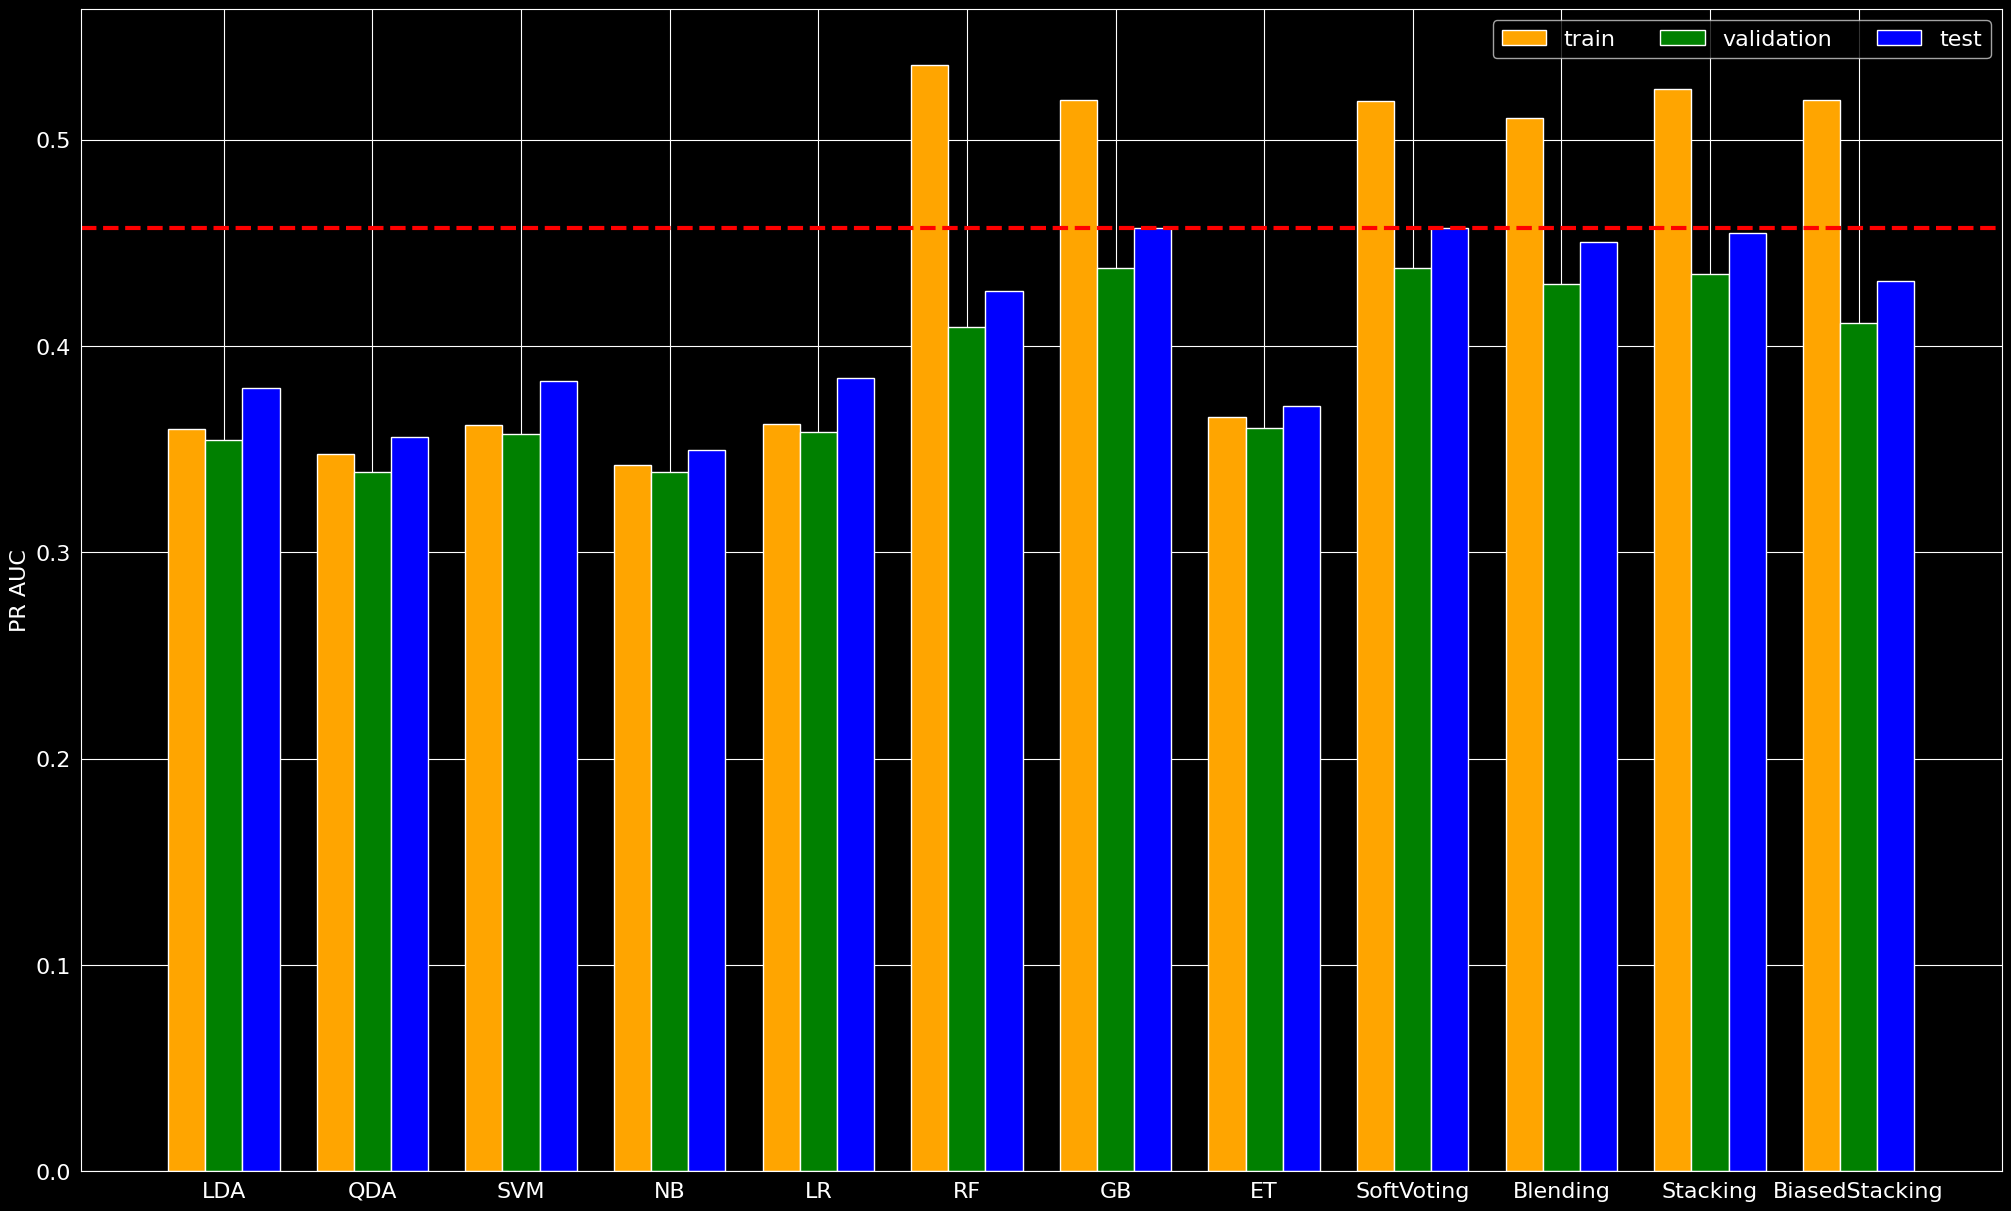

In [24]:
colors = ['orange', 'green', 'blue']

plt.rcParams['font.size'] = 16

labels = tuple(conf[0] for conf in all_models)

x = np.arange(len(labels))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize=(20, 12))

for i, (attribute, measurement) in enumerate(scores.items()):
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color=colors[i])
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel("PR AUC")
ax.set_xticks(x + width, labels)
ax.legend(loc="best", ncols=3)
ax.plot()
ax.axhline(y=max(scores["test"]), color='red', linestyle='--', linewidth=3)

plt.show()